In [ ]:
import glob
import os
import sys
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import matplotlib.cm as cm

cmap = cm.inferno

# load data from parquet files
experiment_df = pl.read_parquet('./Results/optimisation_experiments.parquet')
best_policy_df = pl.read_parquet('./Results/optimisation_best_policies.parquet')
outcomes_df = pl.read_parquet('./Results/optimisation_outcomes.parquet')

## Plot Time-Based Optimisation Policy Evolution

c:\Users\CallumDavidson\Code\MADS\.venv\Lib\site-packages\mpl_toolkits\mplot3d\axes3d.py:866: RuntimeWarning: overflow encountered in scalar subtract
  delta = (upper_t - lower_t) * view_margin


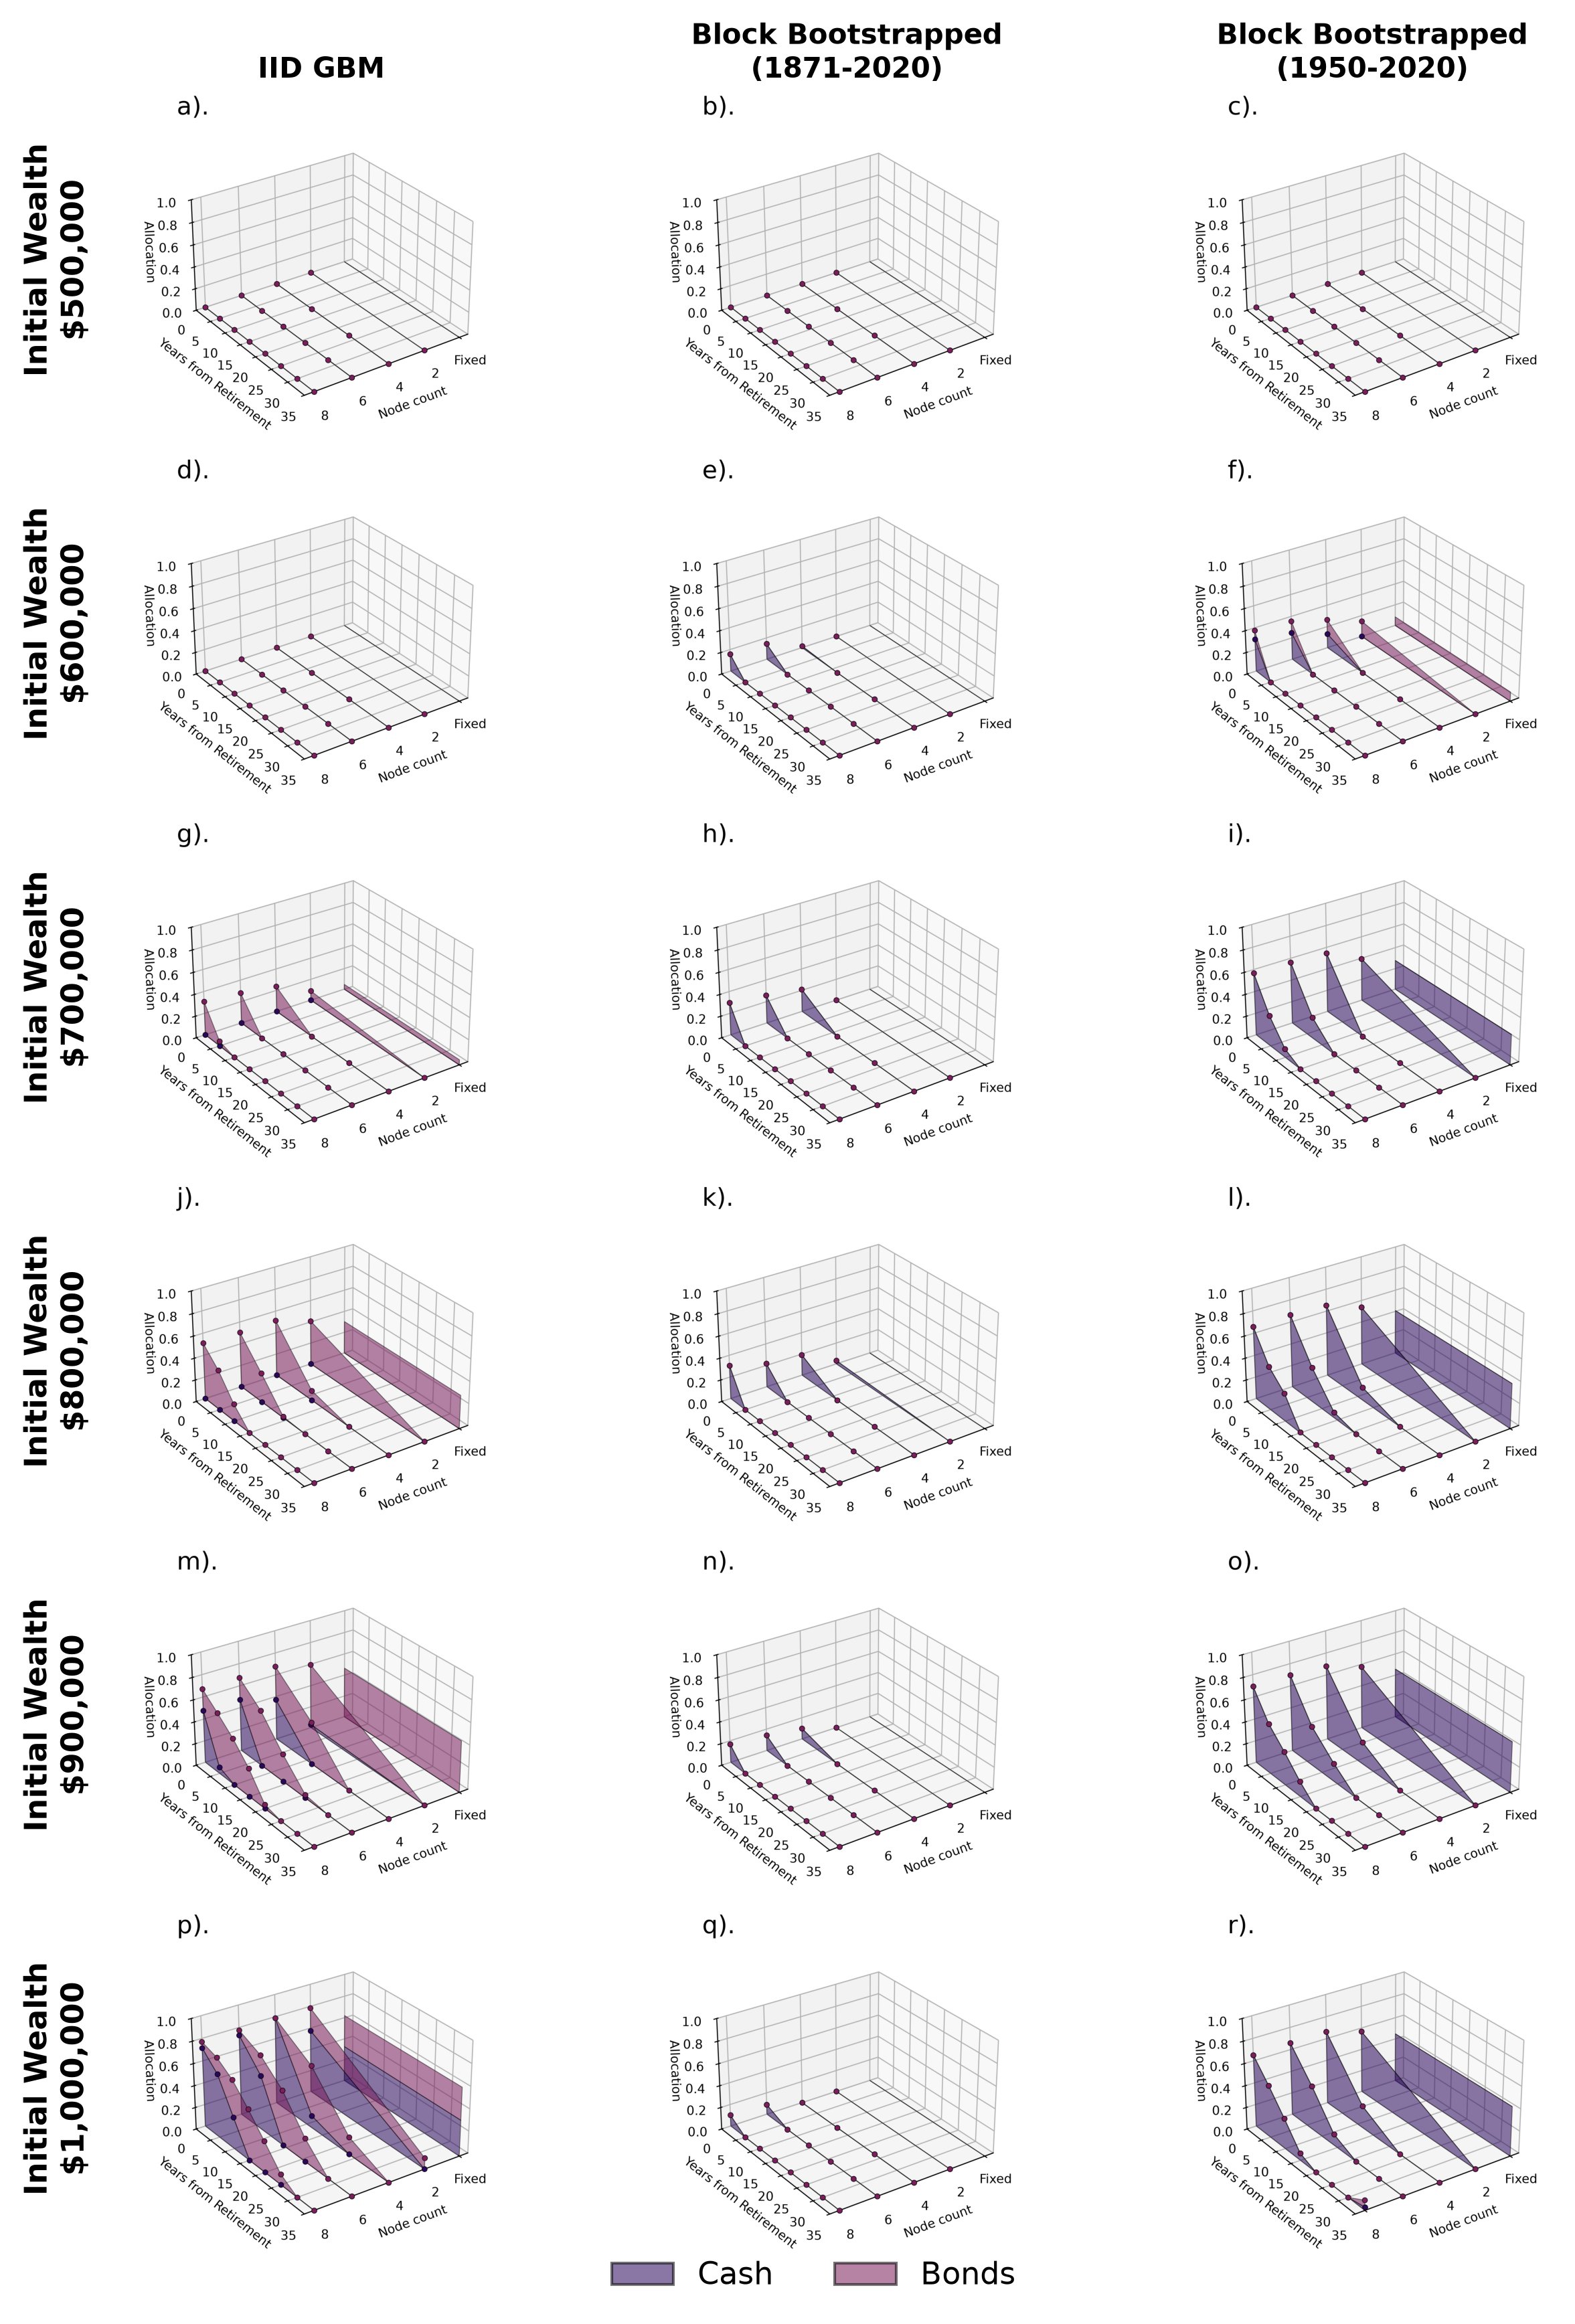

In [ ]:
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch


policy_data = best_policy_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    pl.col('n_wealth_nodes') == 1
)

initial_wealths_to_plot = [
    500_000,
    600_000,
    700_000,
    800_000,
    900_000,
    1_000_000,
]

samplers_to_plot = [
    'cholesky',
    'block_bootstrapped',
    'block_bootstrapped_1950'
]

RETURN_SAMPLER_DISPLAY_NAMES = {
    "cholesky": "IID GBM",
    "block_bootstrapped": "Block Bootstrapped\n(1871-2020)",
    "block_bootstrapped_1950": "Block Bootstrapped\n(1950-2020)",
}

colors = {
    'Cash': '#2a085c',
    'Bonds': '#7a1e5c',
    # 'Stocks': '#d8582e',
}

nodes_to_plot = [
    1,
    2,
    # 3,
    4,
    6,
    8,
]

plot_output_dir = os.path.join('Plots', 'TimeBasedPolicy_vs_NodeCount')
os.makedirs(plot_output_dir, exist_ok=True)

saved_files = []
plot_number = 0

for initial_wealth in initial_wealths_to_plot:
    for sampler in samplers_to_plot:
        fig = plt.figure(figsize=(4, 4.8))
        fig.subplots_adjust(left=0.14, right=0.98, bottom=0.06, top=0.88)
        ax = fig.add_subplot(1, 1, 1, projection='3d')
        ax.set_box_aspect((1.1, 1.1, 0.7))

        this_policy_data = policy_data.filter(
            (pl.col('initial_wealth') == initial_wealth)
            & (pl.col('sampler') == sampler)
        ).sort('n_time_nodes', 'time_node')

        cash_polys = []
        stock_polys = []
        bond_polys = []
        node_counts = []
        cash_points = []
        bond_points = []
        stock_points = []

        time_min = np.inf
        time_max = -np.inf

        # Create polys for time-based policies
        for n in nodes_to_plot:
            policy_subset = this_policy_data.filter(pl.col('n_time_nodes') == n).sort('time_node')

            if n == 1:
                continue

            if len(policy_subset) == 1:
                x = None
            else:
                x = np.asarray(policy_subset['time_node'].to_list(), dtype=float)
            cash = np.asarray(policy_subset['cash'].to_list(), dtype=float)
            stocks = np.asarray(policy_subset['stocks'].to_list(), dtype=float)
            bonds = np.asarray(policy_subset['bonds'].to_list(), dtype=float)

            cash_lower = np.zeros_like(cash)
            cash_upper = cash
            bond_lower = cash_upper
            bond_upper = bond_lower + bonds
            stock_lower = bond_upper
            stock_upper = bond_upper + stocks

            cash_polys.append(list(zip(x, cash_upper)) + list(zip(x[::-1], cash_lower[::-1])))
            # stock_polys.append(list(zip(x, stock_upper)) + list(zip(x[::-1], stock_lower[::-1])))
            bond_polys.append(list(zip(x, bond_upper)) + list(zip(x[::-1], bond_lower[::-1])))
            node_counts.append(n)
            cash_points.extend((n, t, z) for t, z in zip(x, cash_upper))
            bond_points.extend((n, t, z) for t, z in zip(x, bond_upper))
            stock_points.extend((n, t, z) for t, z in zip(x, stock_upper))

            time_min = min(time_min, float(x.min()))    
            time_max = max(time_max, float(x.max()))

        # create the fixed policy subset for plotting
        fixed_policy_subset = this_policy_data.filter(pl.col('n_time_nodes') == 1).sort('time_node')
        x = np.array([time_min, time_max])
        cash = fixed_policy_subset['cash'].first()
        stocks = fixed_policy_subset['stocks'].first()
        bonds = fixed_policy_subset['bonds'].first()

        cash_lower = np.zeros(2)
        cash_upper = np.full(2, cash)
        bond_lower = cash_upper
        bond_upper = bond_lower + bonds
        stock_lower = bond_upper
        stock_upper = bond_upper + stocks

        cash_polys.append(list(zip(x, cash_upper)) + list(zip(x[::-1], cash_lower[::-1])))
        bond_polys.append(list(zip(x, bond_upper)) + list(zip(x[::-1], bond_lower[::-1])))
        node_counts.append(0)


        if this_policy_data.height == 0:
            ax.text2D(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', va='center')
            ax.set_axis_off()
        elif not node_counts:
            ax.text2D(0.5, 0.5, 'Insufficient data', transform=ax.transAxes, ha='center', va='center')
            ax.set_axis_off()
        else:
            for verts, color in [
                (cash_polys, colors['Cash']),
                (bond_polys, colors['Bonds']),
                # (stock_polys, colors['Stocks']),
            ]:
                poly = PolyCollection(
                    verts,
                    facecolors=color,
                    edgecolors='black',
                    linewidths=0.6,
                    alpha=0.55,
                )
                ax.add_collection3d(poly, zs=node_counts, zdir='x')

            # Add scatter points for the time-based policies
            for points, color in [
                (cash_points, colors['Cash']),
                (bond_points, colors['Bonds']),
                # (stock_points, colors['Stocks']),
            ]:
                if points and len(points) > 1:
                    point_array = np.asarray(points, dtype=float)
                    ax.scatter(
                        point_array[:, 0],
                        point_array[:, 1],
                        point_array[:, 2],
                        color=color,
                        edgecolors='black',
                        linewidths=0.4,
                        s=18,
                        depthshade=False,
                    )
            node_counts.sort()
            ax.set_xlim(min(node_counts) - 0.5, max(node_counts) + 0.5)
            ax.set_ylim(time_min, time_max)
            ax.set_zlim(0, 1)
            ax.set_xlabel('Node count', labelpad=4)
            ax.set_xticks(node_counts)
            ax.set_xticklabels(['Fixed' if n == 0 else str(n) for n in node_counts])
            ax.set_ylabel('Years from Retirement', labelpad=4)
            ax.set_zlabel('Allocation', labelpad=0)
            ax.view_init(elev=28, azim=55)

            legend_handles = [
                Patch(facecolor=color, edgecolor='black', alpha=0.55, label=label)
                for label, color in colors.items()
            ]
            # ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=len(colors))
            ax.set_title(
                f"{chr(97 + plot_number)}).", loc='left', size=20
            )
            plot_number += 1

        output_name = f"{sampler}_wealth_{int(initial_wealth):,}.png".replace(',', '')
        output_path = os.path.join(plot_output_dir, output_name)
        fig.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.2)
        saved_files.append(output_path)
        plt.close(fig)

n_rows = len(initial_wealths_to_plot)
n_cols = len(samplers_to_plot)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(8.27, 11.69),  # A4 portrait in inches
    dpi=300,
    squeeze=False,
    constrained_layout=False,
 )

for i, initial_wealth in enumerate(initial_wealths_to_plot):
    for j, sampler in enumerate(samplers_to_plot):
        ax: plt.Axes = axes[i, j]
        filename = f"{sampler}_wealth_{int(initial_wealth)}.png"
        image_path = os.path.join(plot_output_dir, filename)

        if os.path.exists(image_path):
            image = plt.imread(image_path)
            ax.imshow(image)
        else:
            ax.text(0.5, 0.5, 'Missing image', ha='center', va='center', fontsize=9)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

for j, sampler in enumerate(samplers_to_plot):
    axes[0, j].set_title(RETURN_SAMPLER_DISPLAY_NAMES[sampler], fontsize=10, fontweight='bold', pad=8, y=0.94)

for i, initial_wealth in enumerate(initial_wealths_to_plot):
    axes[i, 0].set_ylabel(
        f"Initial Wealth\n${initial_wealth:,.0f}",
        fontsize=11,
        fontweight='bold',
        rotation=90,
        labelpad=16,
    )

legend_handles = [
    Patch(facecolor=color, edgecolor='black', alpha=0.55, label=label)
    for label, color in colors.items()
 ]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.015),
    ncol=len(legend_handles),
    frameon=False,
    fontsize=11,
 )

fig.subplots_adjust(
    left=0.05,
    right=0.99,
    top=0.97,
    bottom=0.04,
    wspace=0.03,
    hspace=0.00,
 )

a4_output_png = './Plots/Time_Based_Policy_Evolution.png'

fig.savefig(a4_output_png, dpi=400)
# fig.savefig(a4_output_pdf)
plt.show()

## Plot Bankruptcy Density of Time-Based Optimisation Policy Evolution

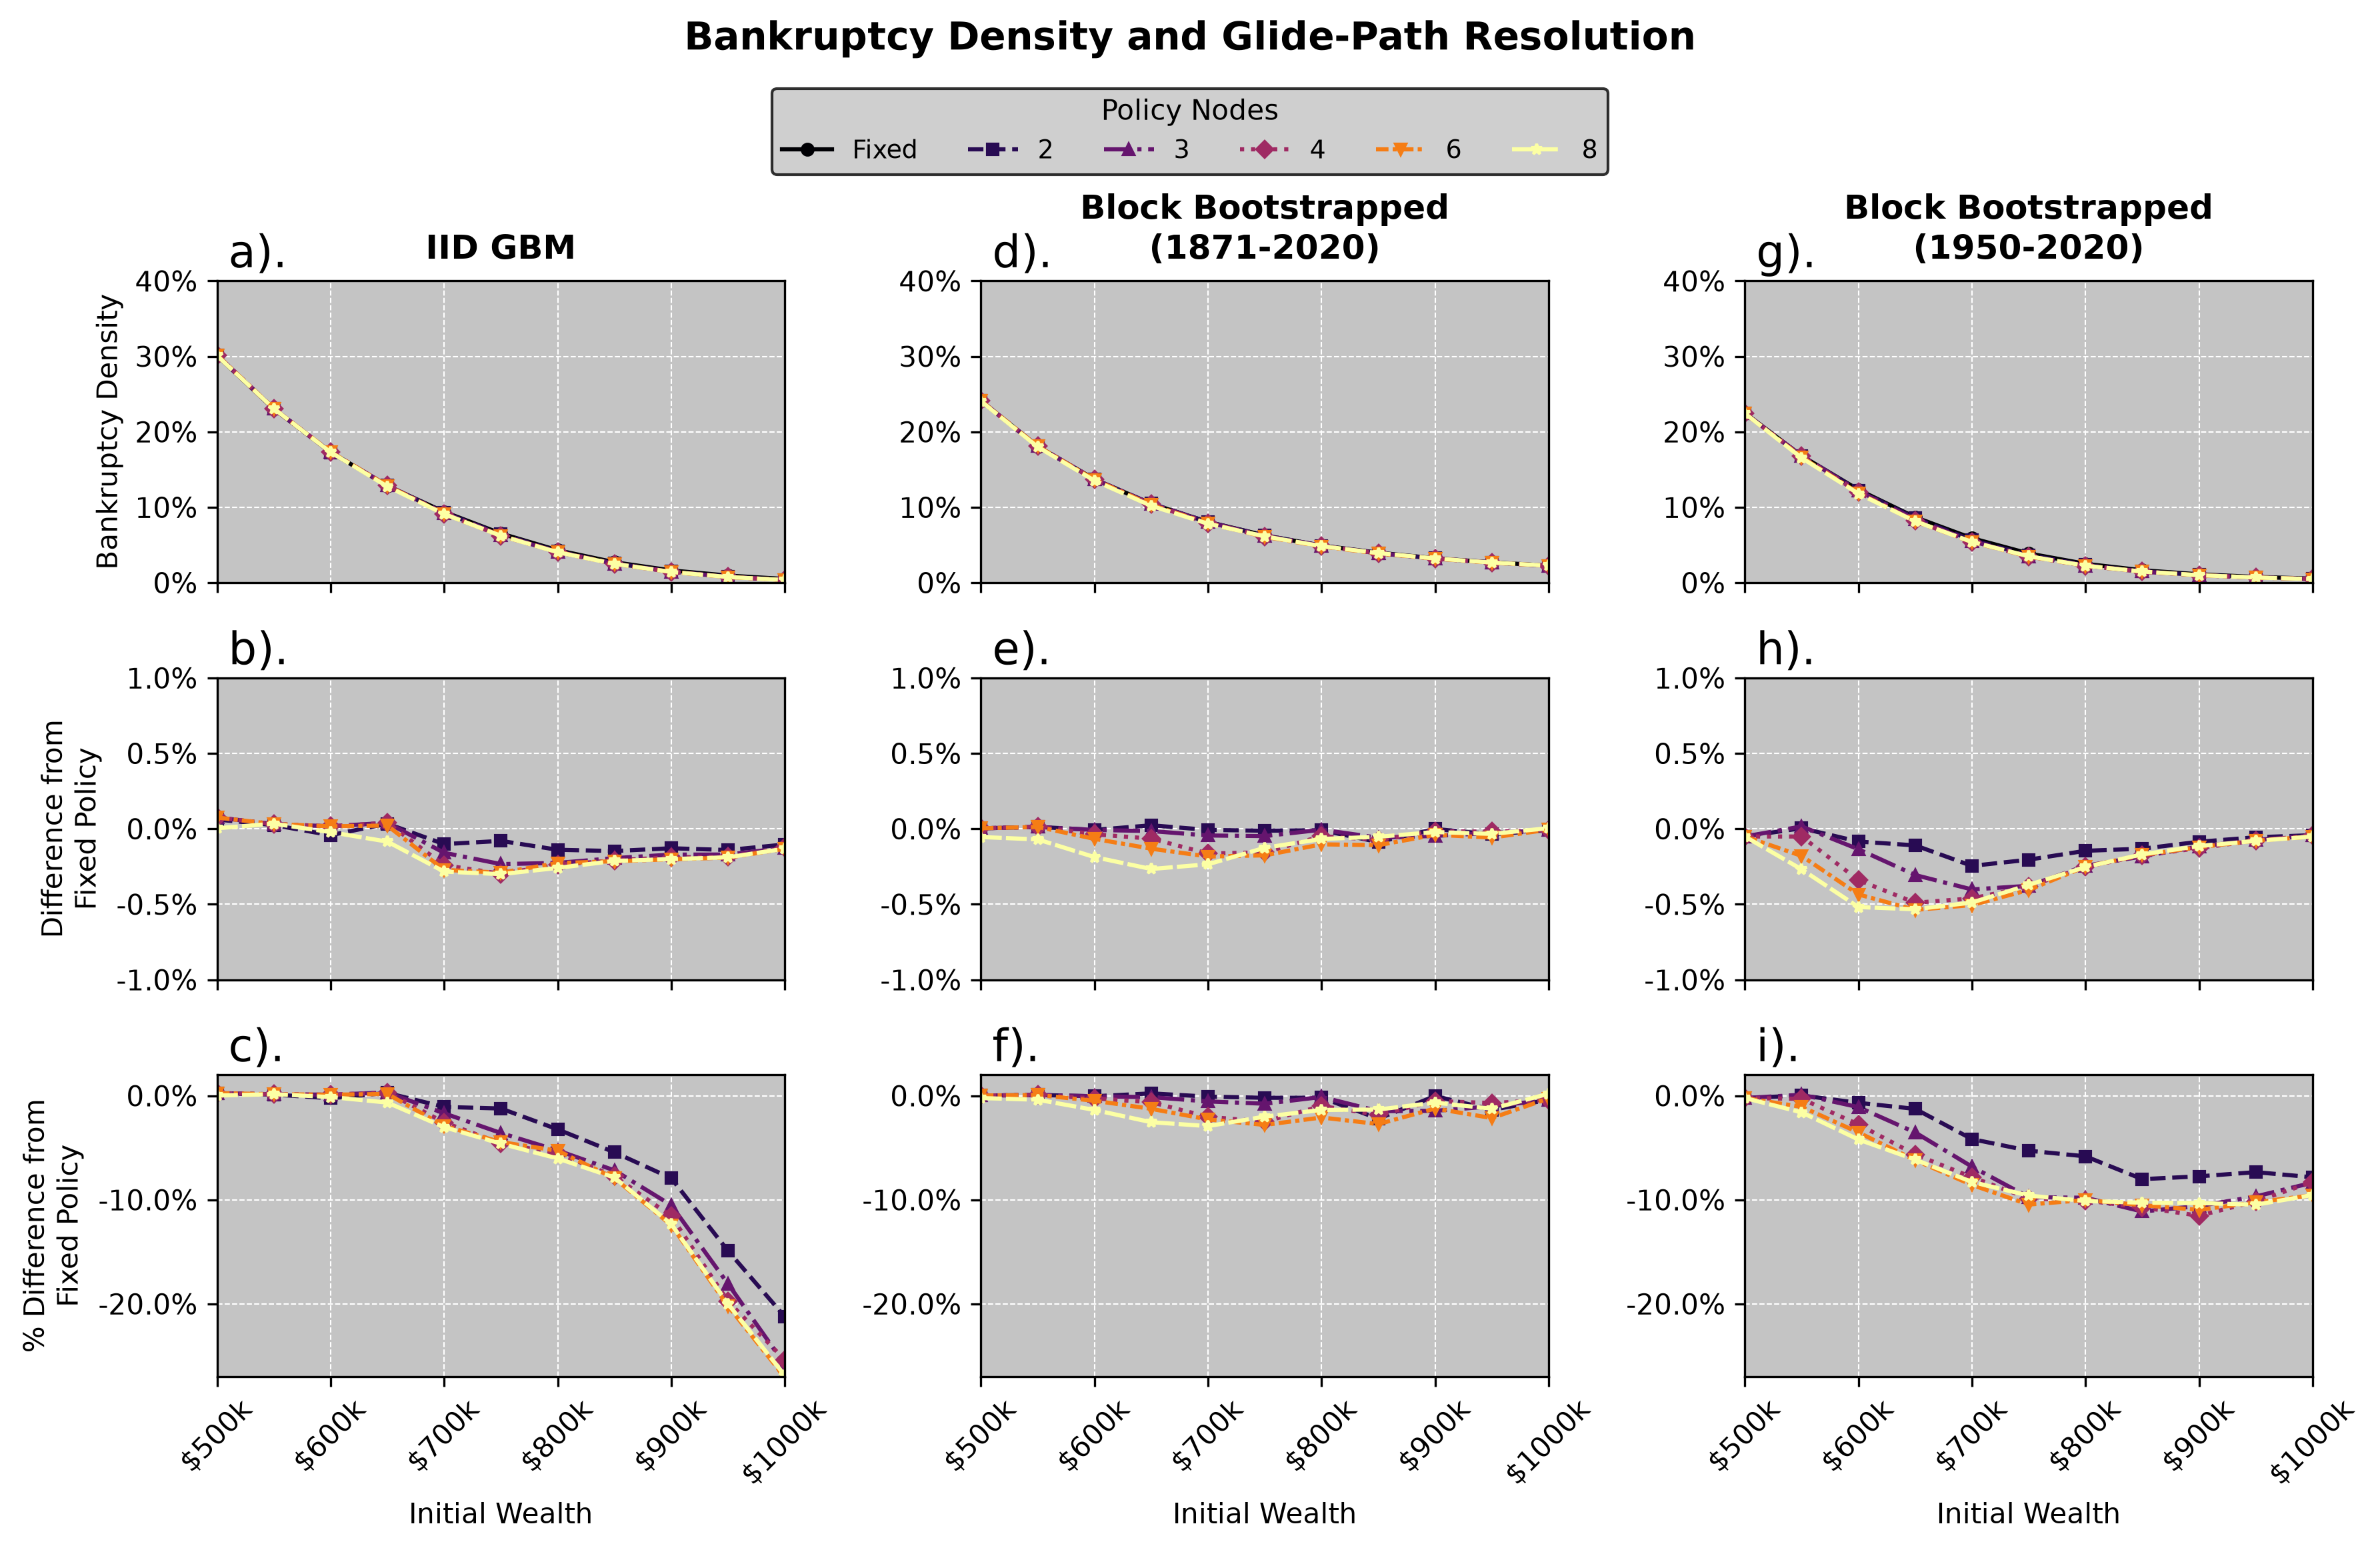

In [ ]:
def get_plot_letter(row_idx: int, col_idx: int, samplers_to_plot: list) -> str:
    letter = chr(ord('a') + row_idx * len(samplers_to_plot) + col_idx)
    return f'{letter}).'

def plot_metric_vs_baseline(
    outcome_data: pl.DataFrame,
    nodes_to_plot: list[int],
    samplers_to_plot: list[str],
    metric: str = 'bankruptcy_density',
    baseline_node_count: int = 2,
    metric_label: str | None = None,
    diff_label: str = 'Difference from Baseline',
    rel_diff_label: str = 'Relative Difference from Baseline',
    top_ylim: tuple[float, float] | None = None,
    diff_ylim: tuple[float, float] | None = None,
    rel_diff_ylim: tuple[float, float] | None = None,
    top_as_percent: bool = True,
    diff_as_percent: bool = True,
    rel_diff_as_percent: bool = True,
) -> tuple[plt.Figure, np.ndarray]:
    fig, axes = plt.subplots(
        3,
        len(samplers_to_plot),
        figsize=(12, 7),
        dpi=300,
        squeeze=True,
        sharex=True,
        # sharey='row',
    )

    linestyles = [None, '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1))]
    markers = ['o', 's', '^', 'D', 'v', '*']

    if len(samplers_to_plot) == 1:
        axes = axes.reshape(3, 1)
        
    metric_label = metric_label or metric.replace('_', ' ').title()

    for j, sampler in enumerate(samplers_to_plot):
        ax1: plt.Axes = axes[0, j]
        ax2: plt.Axes = axes[1, j]
        ax3: plt.Axes = axes[2, j]

        baseline_data = outcome_data.filter(
            (pl.col('sampler') == sampler)
            & (pl.col('n_time_nodes') == baseline_node_count)
).sort('initial_wealth')

        baseline_x = np.asarray(baseline_data['initial_wealth'].to_list(), dtype=float)
        baseline_y = np.asarray(baseline_data[metric].to_list(), dtype=float)

        baseline_mask = np.isfinite(baseline_x) & np.isfinite(baseline_y)
        baseline_x = baseline_x[baseline_mask]
        baseline_y = baseline_y[baseline_mask]

        sampler_common_x = []

        for n in nodes_to_plot:

            this_data = outcome_data.filter(
                (pl.col('sampler') == sampler)
                & (pl.col('n_time_nodes') == n)
            ).sort('initial_wealth')

            x = np.asarray(this_data['initial_wealth'].to_list(), dtype=float)
            y = np.asarray(this_data[metric].to_list(), dtype=float)

            mask = np.isfinite(x) & np.isfinite(y)
            x = x[mask]
            y = y[mask]

            common_x, base_idx, this_idx = np.intersect1d(baseline_x, x, return_indices=True)
            if common_x.size == 0:
                print(
                    f"Warning: no overlapping initial_wealth values for sampler '{sampler}' and n_time_nodes {n}. Skipping."
                )
                continue

            baseline_y_aligned = baseline_y[base_idx]
            y_aligned = y[this_idx]

            diff_abs = y_aligned - baseline_y_aligned
            diff_rel = np.divide(
                y_aligned,
                baseline_y_aligned,
                out=np.full_like(y_aligned, 1, dtype=float),
                where=baseline_y_aligned != 0,
            ) - 1.0

            c = cm.inferno((n - min(nodes_to_plot)) / (max(nodes_to_plot) - min(nodes_to_plot)))
            linestyle = linestyles[nodes_to_plot.index(n) % len(linestyles)]
            marker = markers[nodes_to_plot.index(n) % len(markers)]

            ax1.plot(
                common_x,
                y_aligned,
                marker=marker,
                markersize=4,
                label=n if n != baseline_node_count else "Fixed",
                color=c,
                linestyle=linestyle,
            )

            sampler_common_x.append(common_x)

            if n == baseline_node_count:
                continue

            ax2.plot(
                common_x,
                diff_abs,
                marker=marker,
                markersize=4,
                label=f"{n}",
                color=c,
                linestyle=linestyle,
            )

            ax3.plot(
                common_x,
                diff_rel,
                marker=marker,
                markersize=4,
                label=f"{n}",
                color=c,
                linestyle=linestyle,
            )

        if sampler_common_x:
            x_joined = np.concatenate(sampler_common_x)
            x_min = float(np.nanmin(x_joined))
            x_max = float(np.nanmax(x_joined))
        else:
            fallback_x = np.asarray(
                outcome_data.filter(pl.col('sampler') == sampler)['initial_wealth'].to_list(),
                dtype=float,
            )
            fallback_x = fallback_x[np.isfinite(fallback_x)]
            if fallback_x.size > 0:
                x_min = float(np.nanmin(fallback_x))
                x_max = float(np.nanmax(fallback_x))
            else:
                x_min, x_max = 0.0, 1.0
        ax1.set_xlim(x_min, x_max)
        ax2.set_xlim(x_min, x_max)
        ax3.set_xlim(x_min, x_max)

        ax1.text(0.02, 1.01, get_plot_letter(j, 0, samplers_to_plot), transform=ax1.transAxes, fontsize=16, va='bottom', ha='left')
        ax2.text(0.02, 1.01, get_plot_letter(j, 1, samplers_to_plot), transform=ax2.transAxes, fontsize=16, va='bottom', ha='left')
        ax3.text(0.02, 1.01, get_plot_letter(j, 2, samplers_to_plot), transform=ax3.transAxes, fontsize=16, va='bottom', ha='left')



        if top_ylim is not None:
            ax1.set_ylim(*top_ylim)
        if diff_ylim is not None:
            ax2.set_ylim(*diff_ylim)
        if rel_diff_ylim is not None:
            ax3.set_ylim(*rel_diff_ylim)
        
        if top_as_percent:
            ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
        if diff_as_percent:
            ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
        if rel_diff_as_percent:
            ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

        ax1.set_title(RETURN_SAMPLER_DISPLAY_NAMES[sampler], fontsize=12, fontweight='bold', pad=8)
        ax3.set_xlabel('Initial Wealth', fontsize=10)

    for plot in axes.flatten():
        plot.grid(True, which='both', linestyle='--', linewidth=0.5, color='white')
        plot.set_facecolor('#c4c4c4')

    axes[0, 0].set_ylabel(metric_label, fontsize=10)
    axes[1, 0].set_ylabel(diff_label, fontsize=10)
    axes[2, 0].set_ylabel(rel_diff_label, fontsize=10)

    def _safe_k_formatter(x: float, _: int) -> str:
        if not np.isfinite(x):
            return ''
        return f'${int(x/1000)}k'

    for j in range(len(samplers_to_plot)):
        axes[2, j].xaxis.set_major_formatter(plt.FuncFormatter(_safe_k_formatter))
        axes[2, j].tick_params(axis='x', rotation=45)

    # Use explicit spacing to avoid rare tight_layout NaN issues with sparse axes.
    # fig.subplots_adjust(left=0.09, right=0.99, top=0.94, bottom=0.12, wspace=0.2, hspace=0.12)
    fig.tight_layout()
    
    # Add figure-level legend below suptitle
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles=handles,
        labels=labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.06),
        ncol=len(nodes_to_plot),
        fontsize=9,
        frameon=True,
        title='Policy Nodes',
        title_fontsize=10,
        facecolor='#c4c4c4',
        edgecolor='black'
    )
    
    return fig, axes


outcome_data = outcomes_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    pl.col('n_wealth_nodes') == 1
)
# Example usage: swap metric='median_terminal_wealth' or 'mean_terminal_wealth' etc.
fig, axes = plot_metric_vs_baseline(
    outcome_data=outcome_data,
    nodes_to_plot=[1, 2, 3, 4, 6, 8],
    samplers_to_plot=samplers_to_plot,
    metric='bankruptcy_density',
    baseline_node_count=1,
    metric_label='Bankruptcy Density',
    diff_label='Difference from\nFixed Policy',
    rel_diff_label='% Difference from\nFixed Policy',
    top_ylim=(0, 0.4),
    diff_ylim=(-0.01, 0.01),
    rel_diff_ylim=(-0.27, 0.02),
    top_as_percent=True,
    diff_as_percent=True,
    rel_diff_as_percent=True,
)

plt.suptitle('Bankruptcy Density and Glide-Path Resolution', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Time_Based_Policy_Bankruptcy_Density_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

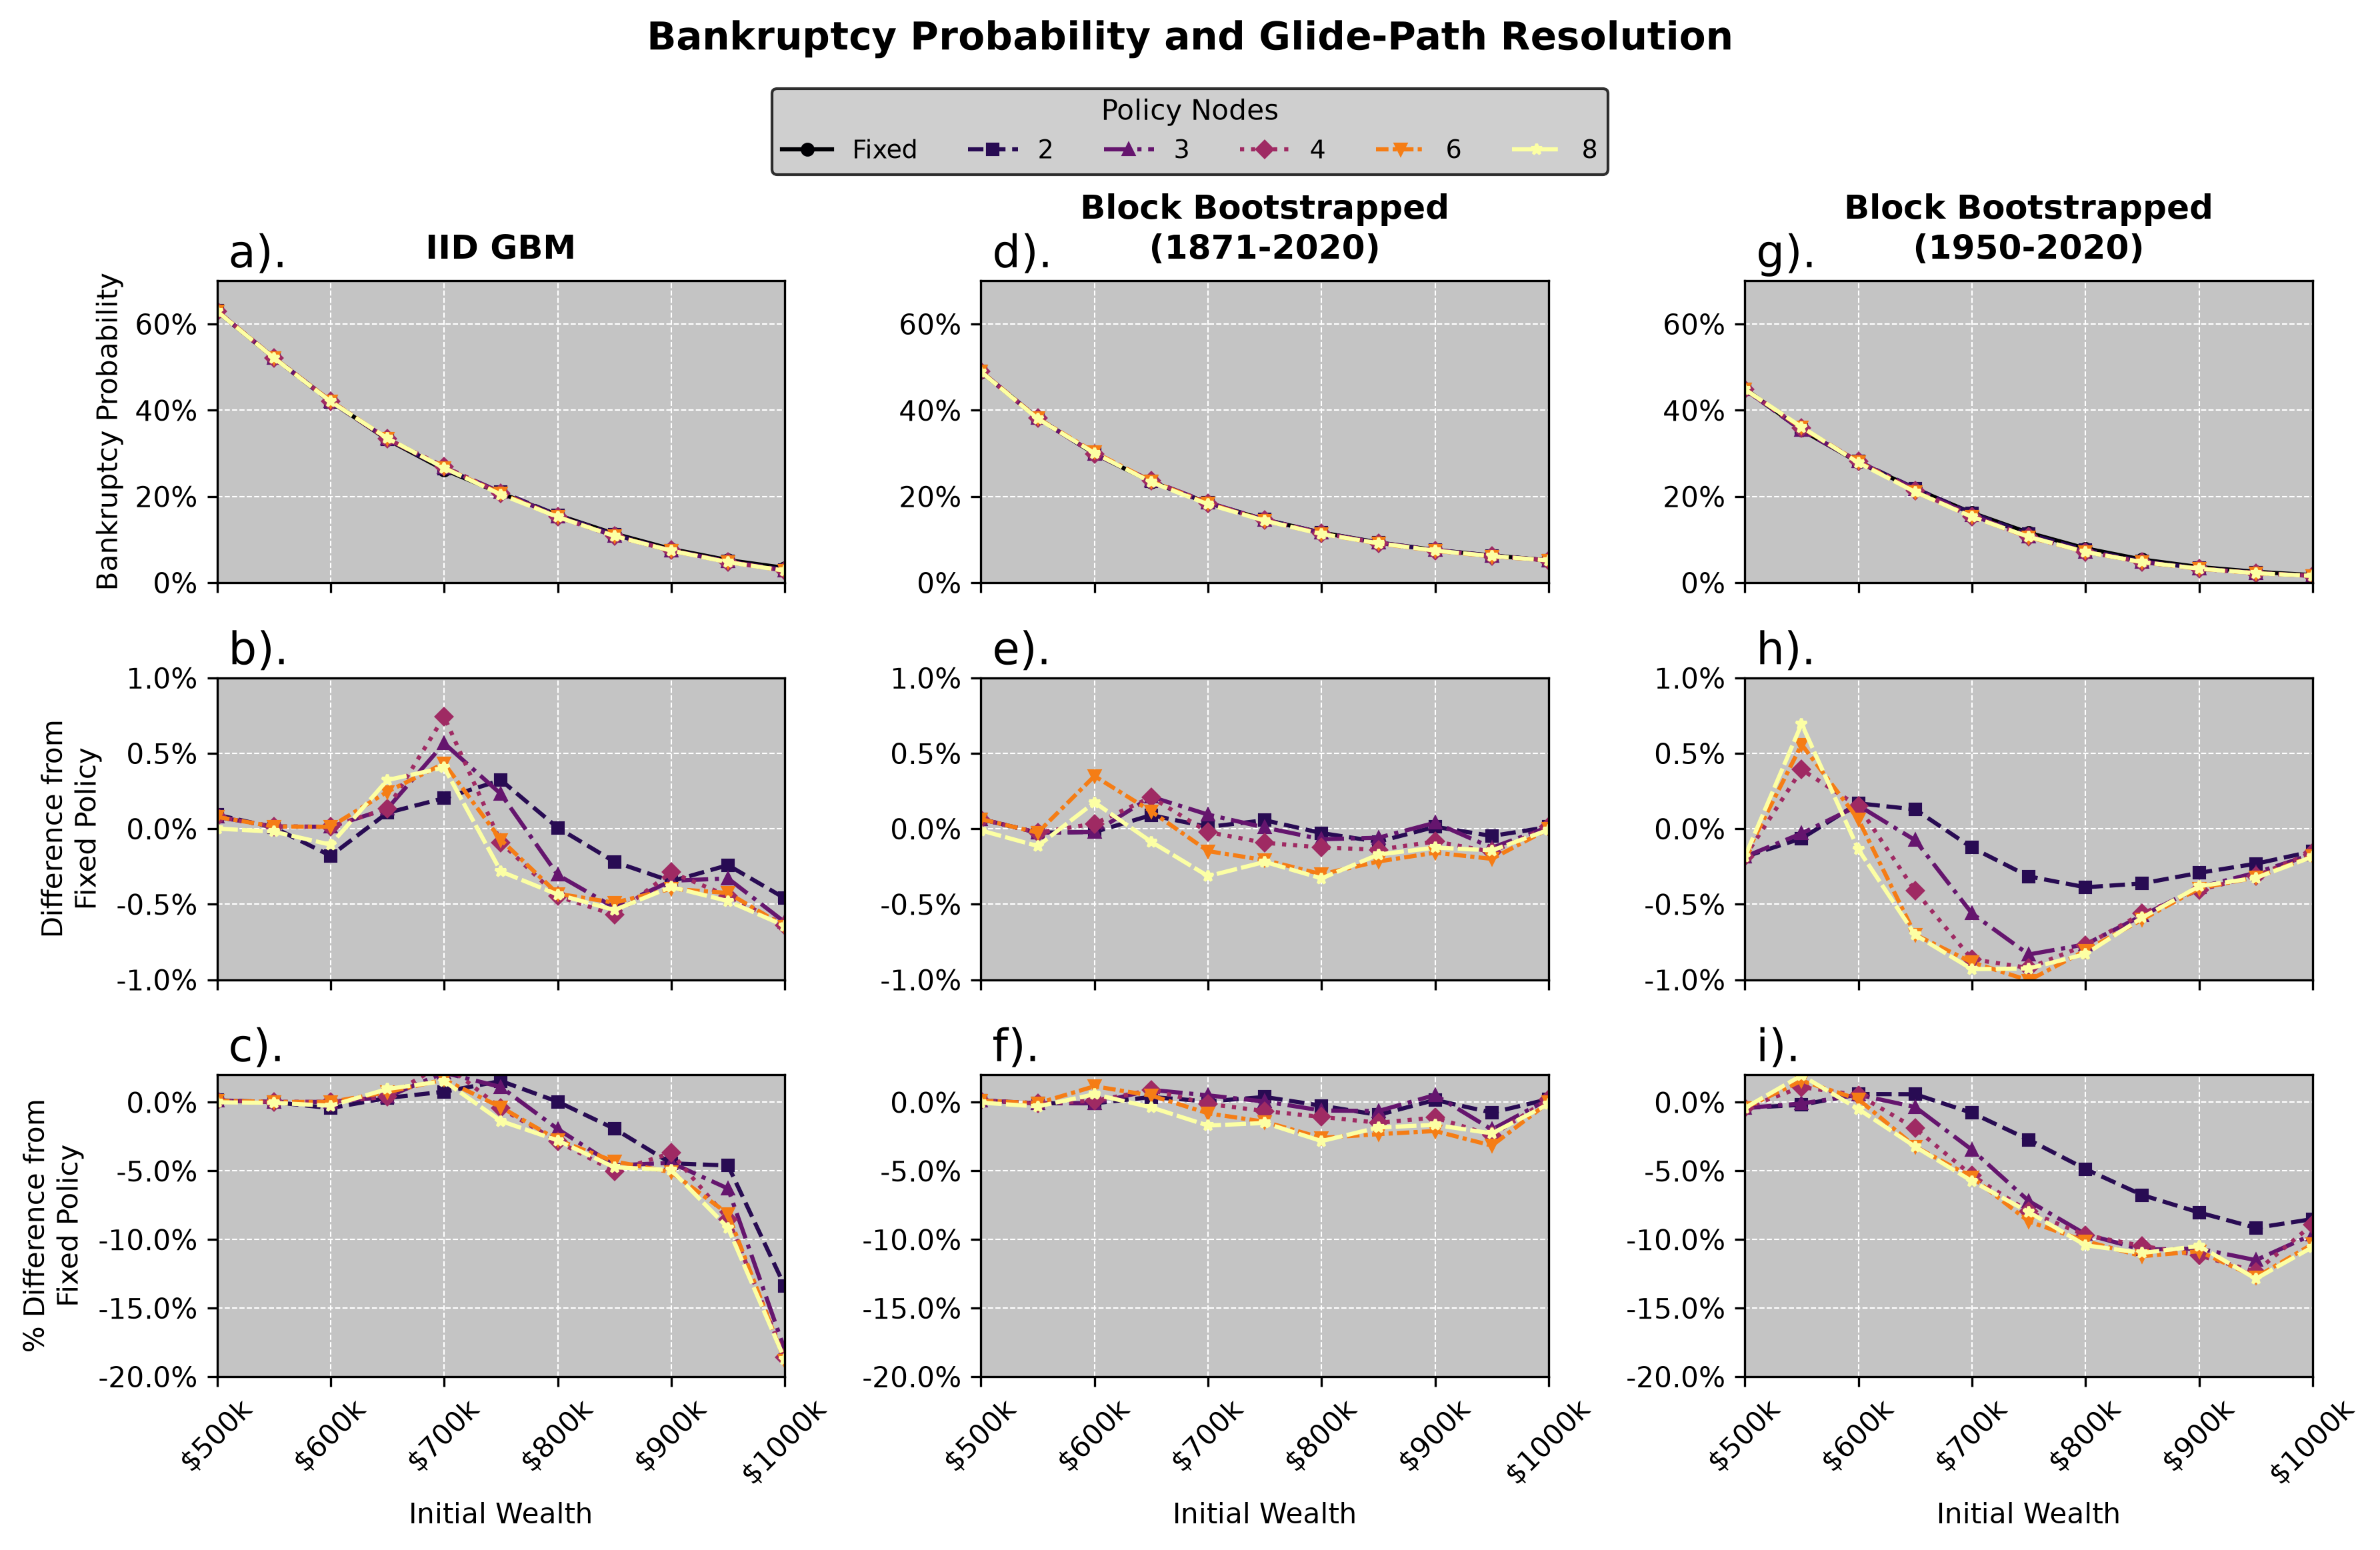

In [ ]:
fig, axes = plot_metric_vs_baseline(
    outcome_data=outcome_data,
    nodes_to_plot=[1, 2, 3, 4, 6, 8],
    samplers_to_plot=samplers_to_plot,
    metric='bankruptcy_probability',
    baseline_node_count=1,
    rel_diff_label='% Difference from\nFixed Policy',
    metric_label='Bankruptcy Probability',
    diff_label='Difference from\nFixed Policy',

    top_ylim=(0, 0.7),
    diff_ylim=(-0.01, 0.01),
    rel_diff_ylim=(-0.2, 0.02),
    top_as_percent=True,
    diff_as_percent=True,
    rel_diff_as_percent=True,
)

plt.suptitle('Bankruptcy Probability and Glide-Path Resolution', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Time_Based_Policy_Bankruptcy_Probability_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

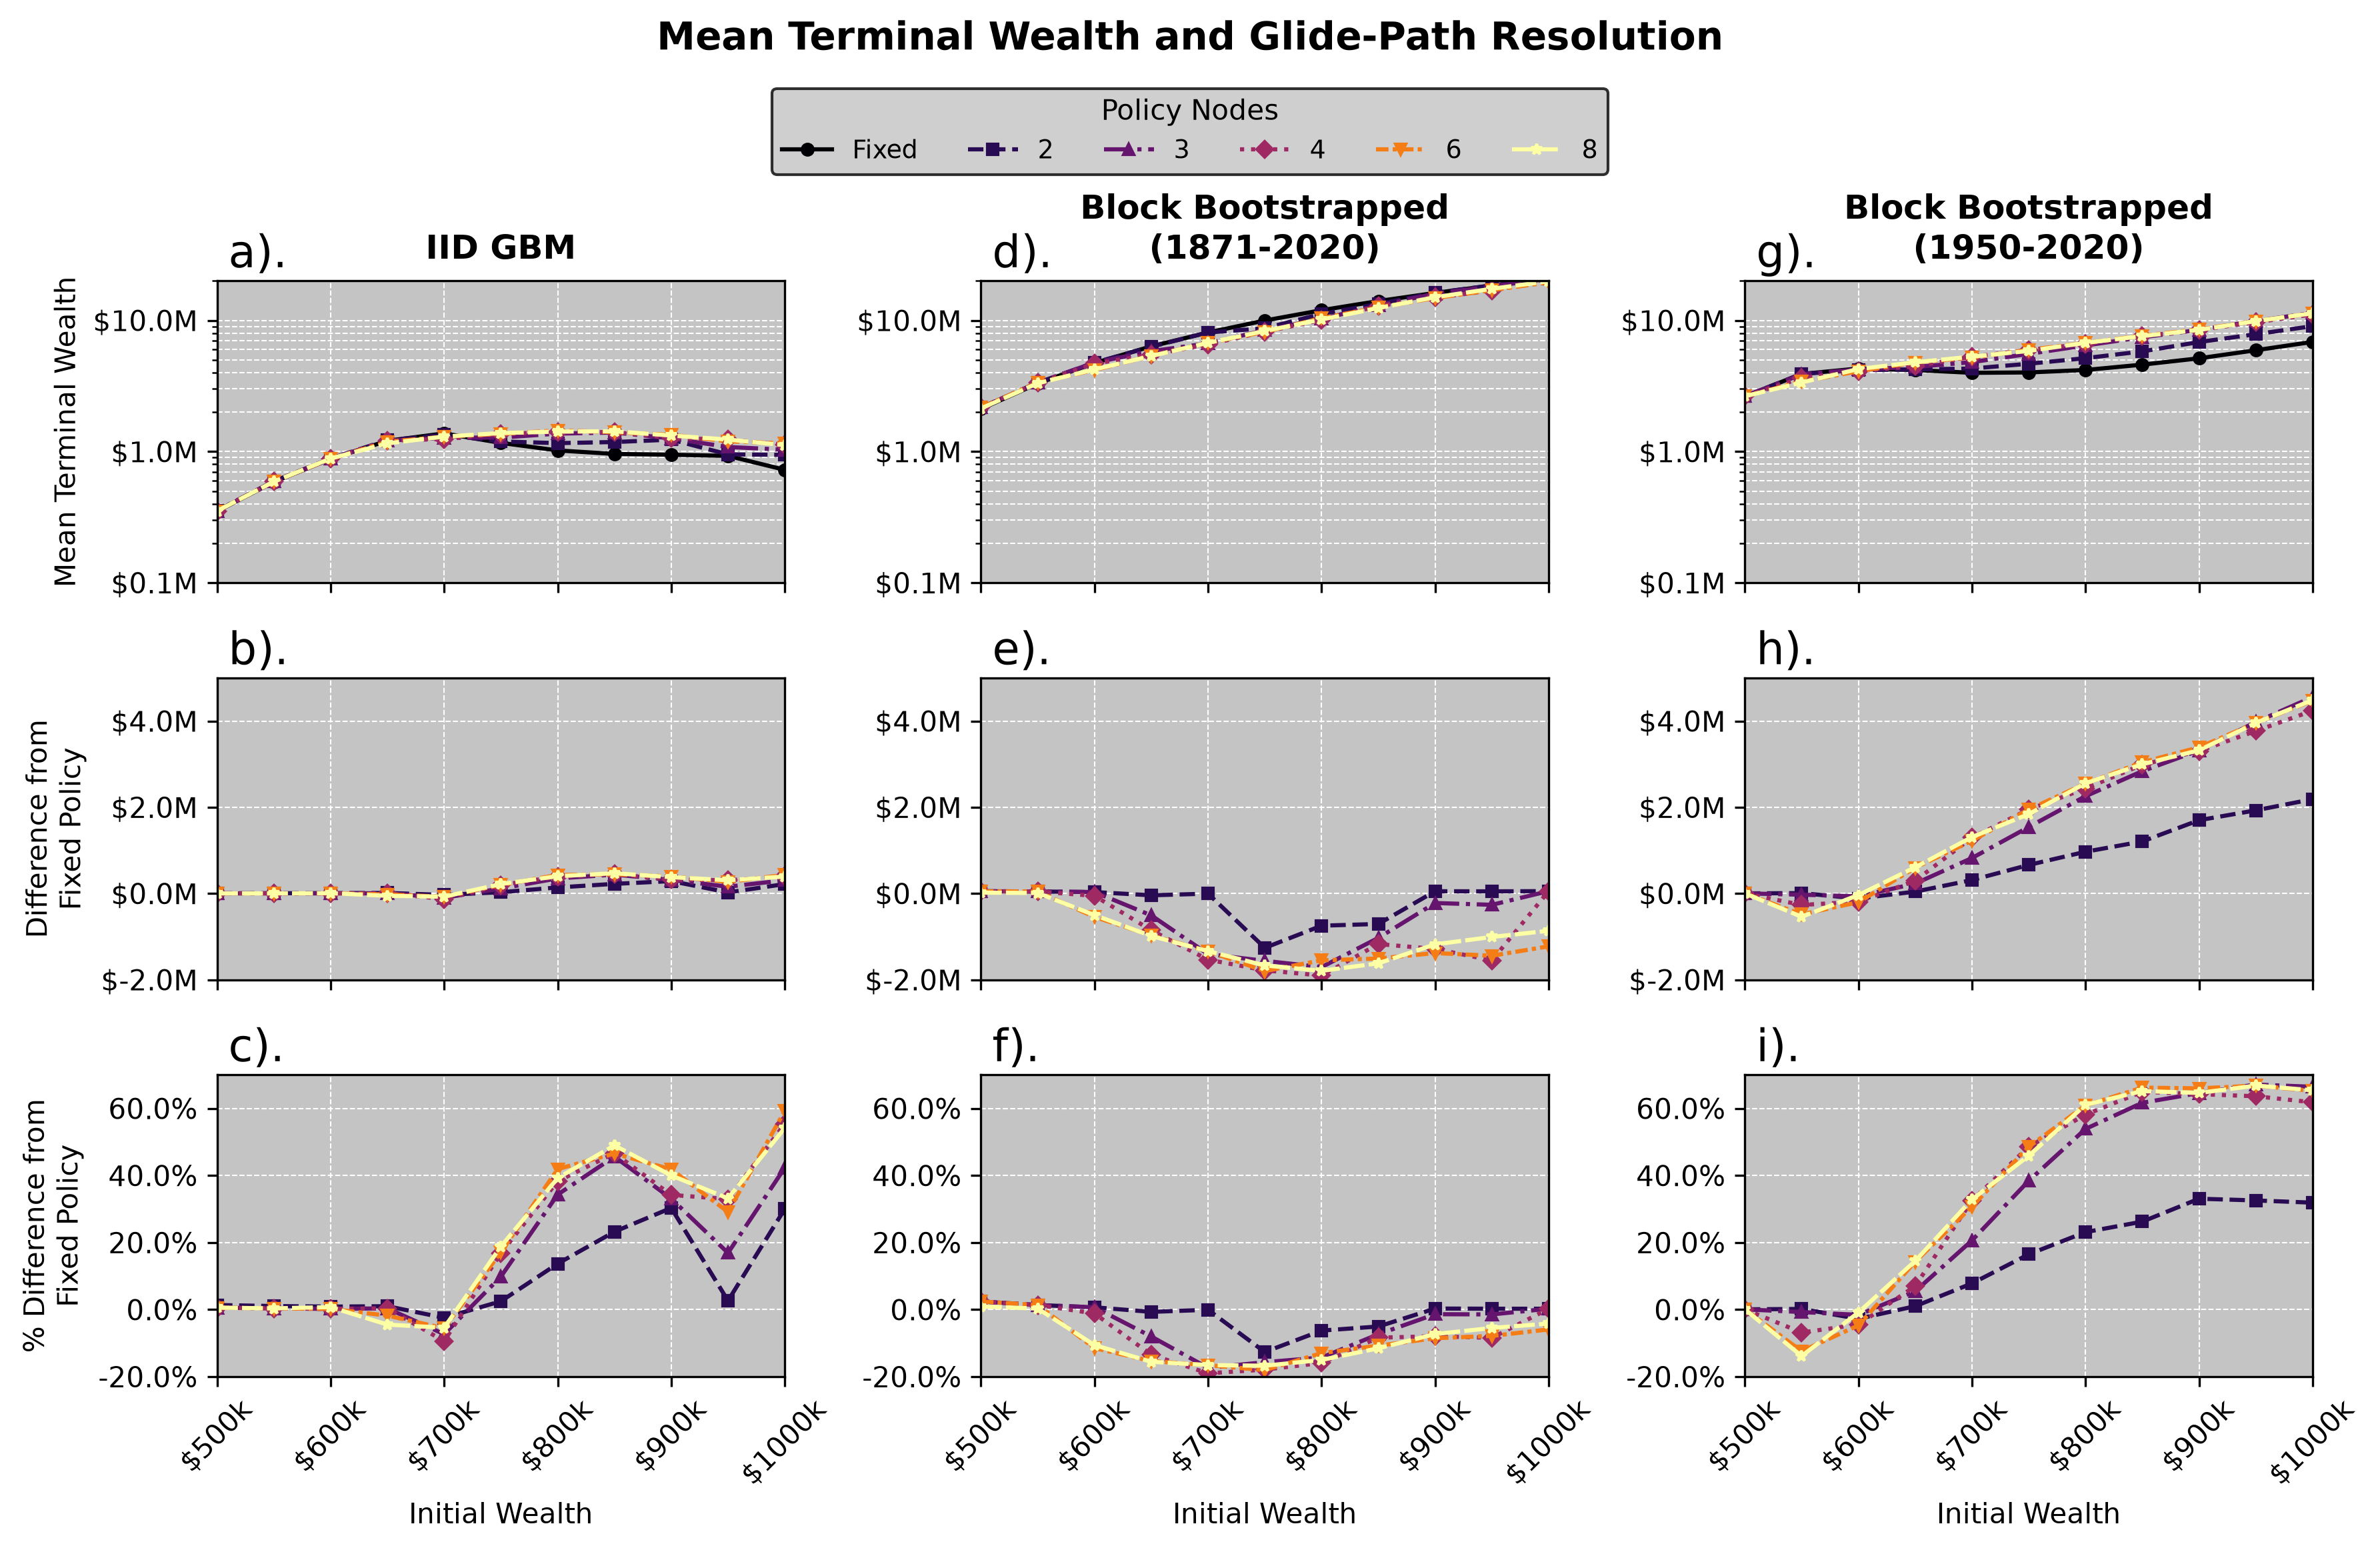

In [ ]:
fig, axes = plot_metric_vs_baseline(
    outcome_data=outcome_data,
    nodes_to_plot=[1, 2, 3, 4, 6, 8],
    samplers_to_plot=samplers_to_plot,
    metric='mean_terminal_wealth',
    baseline_node_count=1,
    metric_label='Mean Terminal Wealth',
    diff_label='Difference from\nFixed Policy',
    rel_diff_label='% Difference from\nFixed Policy',
    top_ylim=(1e5, 2e7),
    diff_ylim=(-2e6, 5e6),
    rel_diff_ylim=(-0.2, 0.7),
    
    top_as_percent=False,
    diff_as_percent=False,
)

for j, sampler in enumerate(samplers_to_plot):
    for i in range(axes.shape[0]):
        axes[0, j].set_yscale('log')

currency_fmt = plt.FuncFormatter(lambda y, _: f'${y/1_000_000:.1f}M' if np.isfinite(y) else '')
for j in range(len(samplers_to_plot)):
    axes[0, j].yaxis.set_major_formatter(currency_fmt)
    axes[1, j].yaxis.set_major_formatter(currency_fmt)

plt.suptitle('Mean Terminal Wealth and Glide-Path Resolution', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Time_Based_Policy_Mean_Terminal_Wealth_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)
# fig.canvas.draw_idle()

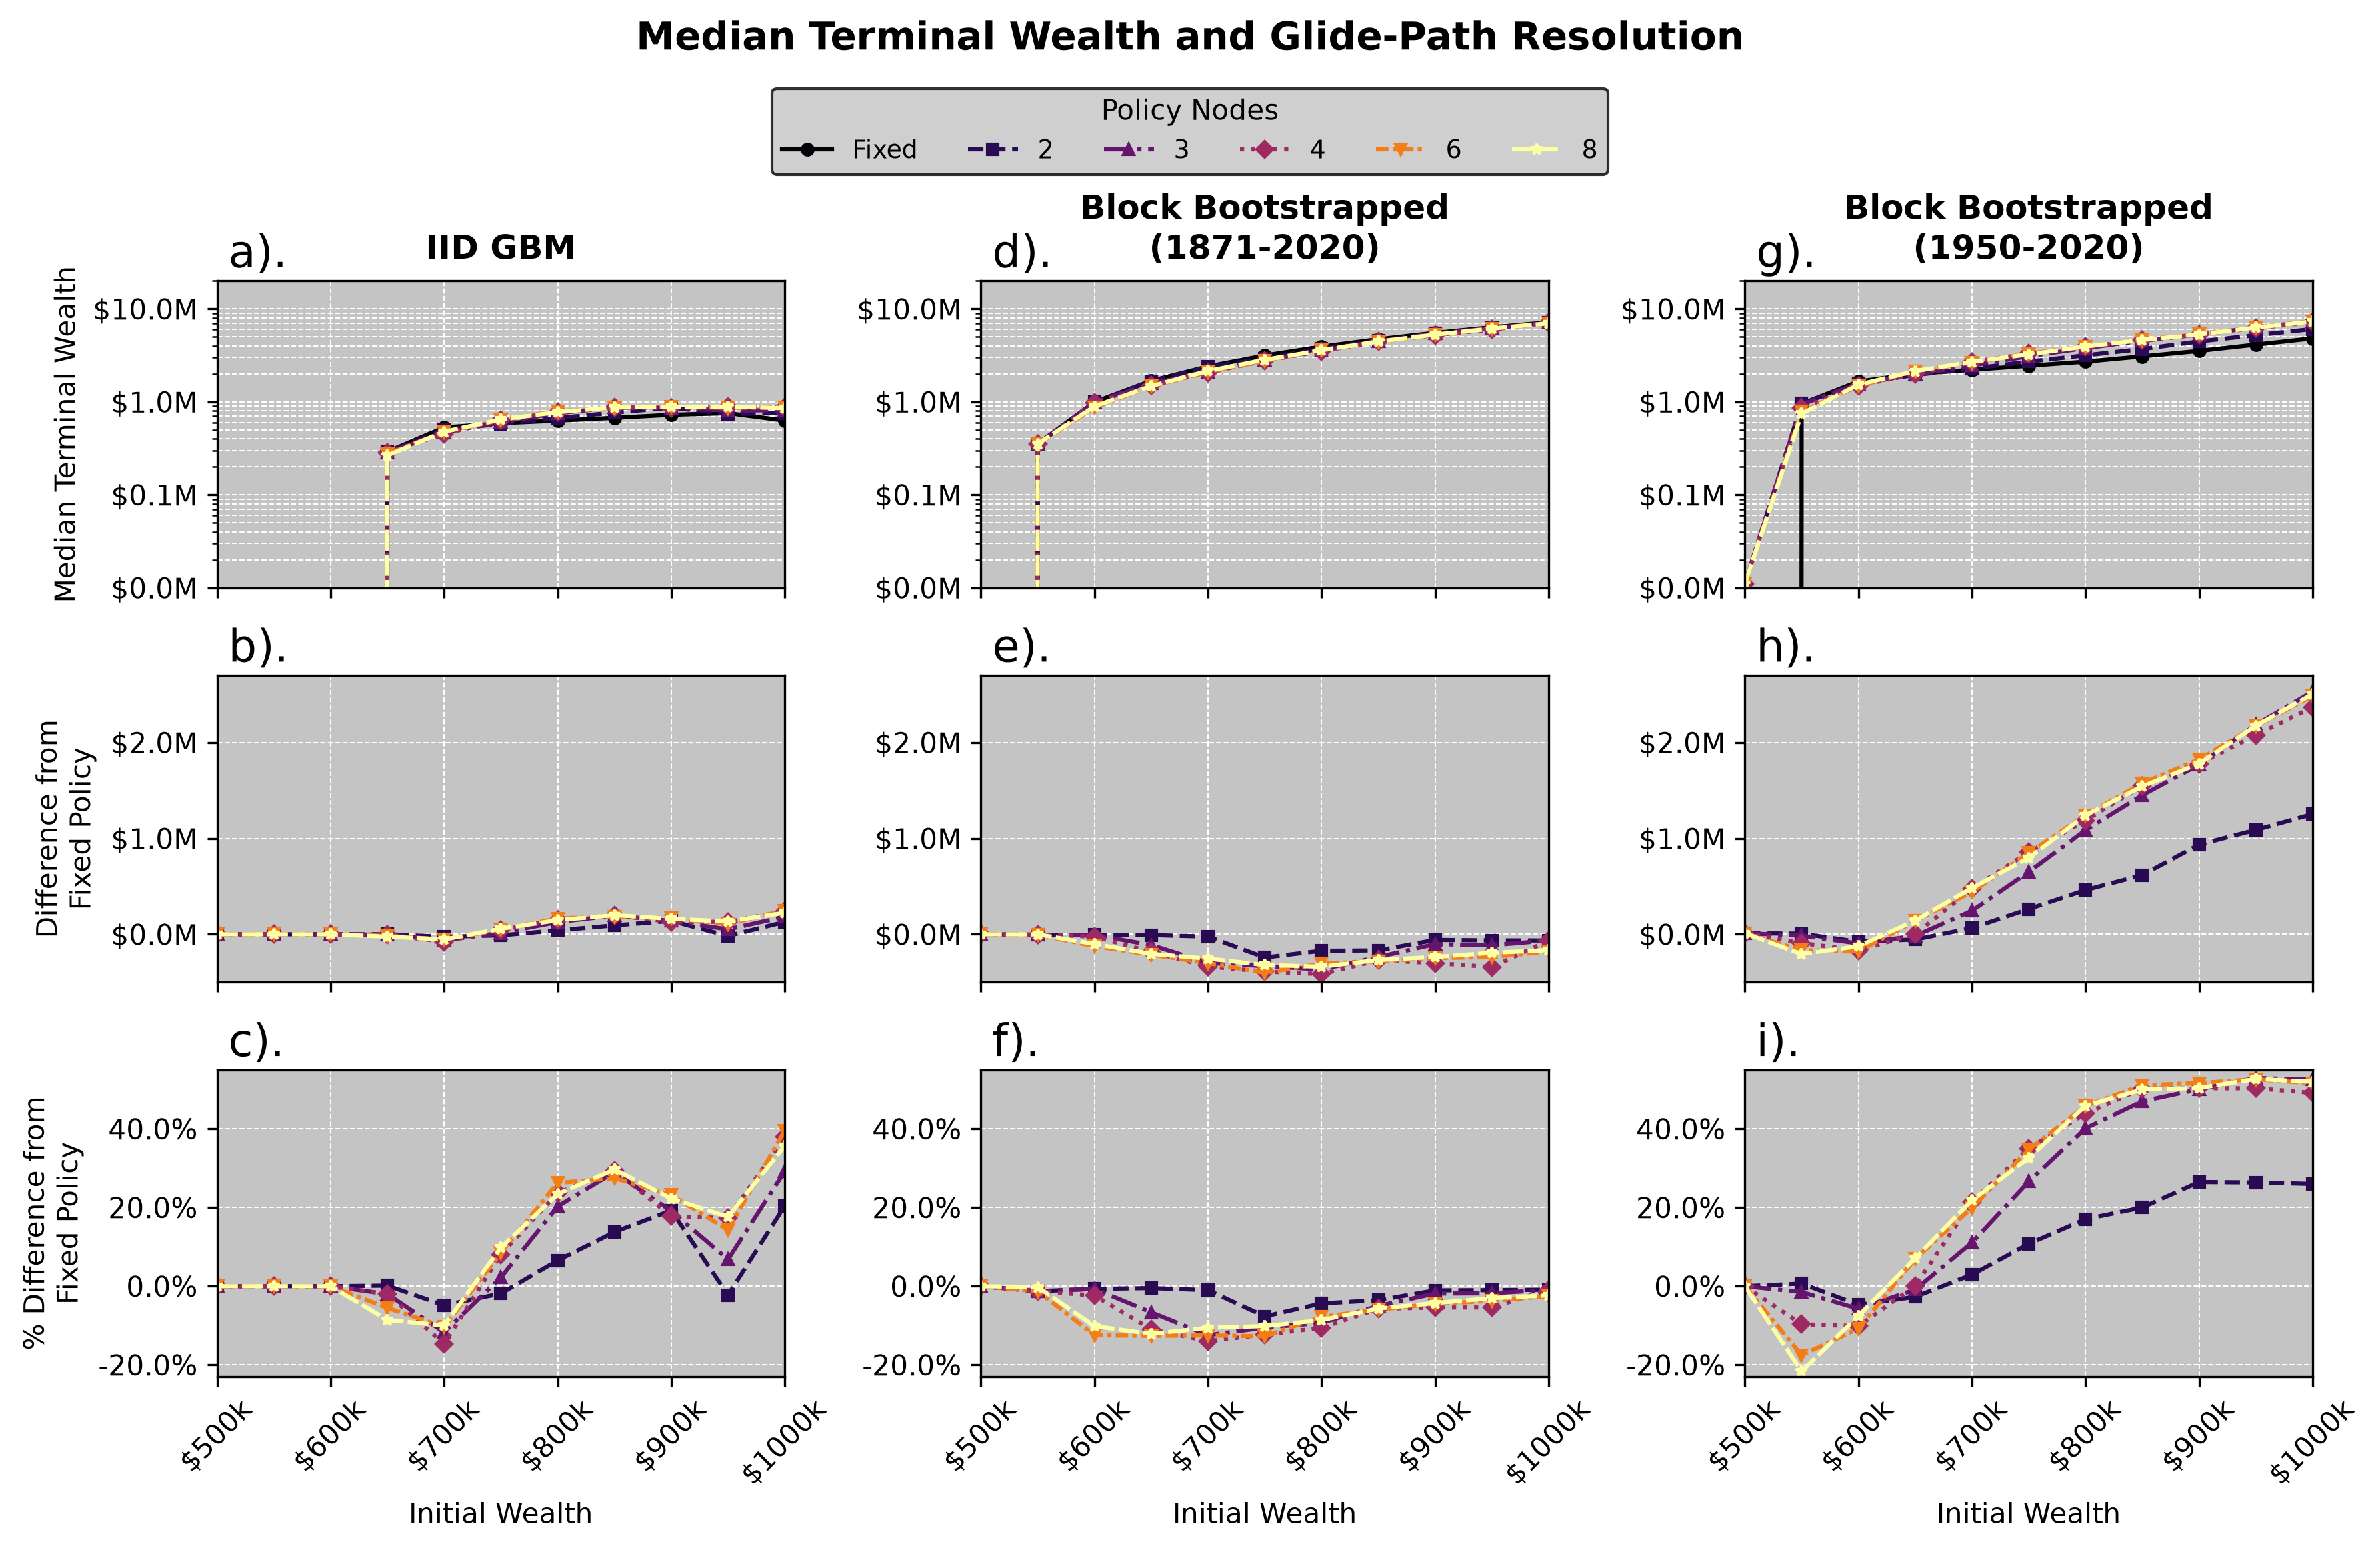

In [ ]:
fig, axes = plot_metric_vs_baseline(
    outcome_data=outcome_data.with_columns(pl.col('median_terminal_wealth').cast(pl.Int64)),
    nodes_to_plot=[1, 2, 3, 4, 6, 8],
    samplers_to_plot=samplers_to_plot,
    metric='median_terminal_wealth',
    baseline_node_count=1,
    metric_label='Median Terminal Wealth',
    diff_label='Difference from\nFixed Policy',
    rel_diff_label='% Difference from\nFixed Policy',
    top_ylim=(1e4, 2e7),
    diff_ylim=(-5e5, 2.7e6),
    rel_diff_ylim=(-0.23, 0.55),
    top_as_percent=False,
    diff_as_percent=False,
)

for j, sampler in enumerate(samplers_to_plot):
    for i in range(axes.shape[0]):
        axes[0, j].set_yscale('log')

currency_fmt = plt.FuncFormatter(lambda y, _: f'${y/1_000_000:.1f}M' if np.isfinite(y) else '')
for j in range(len(samplers_to_plot)):
    axes[0, j].yaxis.set_major_formatter(currency_fmt)
    axes[1, j].yaxis.set_major_formatter(currency_fmt)

plt.suptitle('Median Terminal Wealth and Glide-Path Resolution', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Time_Based_Policy_Median_Terminal_Wealth_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

In [ ]:
policy_data

experiment_file,bankruptcy_probability,bankruptcy_density,mean_terminal_wealth,std_terminal_wealth,median_terminal_wealth,p05_terminal_wealth,p10_terminal_wealth,p25_terminal_wealth,p75_terminal_wealth,p90_terminal_wealth,p95_terminal_wealth,initial_wealth,n_time_nodes,n_wealth_nodes,sampler
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str
"""../Time Responsive Policy/Resu…",0.630265,0.301575,354846.403638,1.1053e6,0.01,0.0,0.0,0.0,64351.789064,1.1019e6,2.1007e6,500000.0,2,1,"""cholesky"""
"""../Time Responsive Policy/Resu…",0.630125,0.301709,352081.330114,1.0928e6,0.01,0.0,0.0,0.0,63940.6583,1.0998e6,2.0910e6,500000.0,3,1,"""cholesky"""
"""../Time Responsive Policy/Resu…",0.630125,0.301709,352081.330114,1.0928e6,0.01,0.0,0.0,0.0,63940.6583,1.0998e6,2.0910e6,500000.0,4,1,"""cholesky"""
"""../Time Responsive Policy/Resu…",0.630125,0.301709,352081.330114,1.0928e6,0.01,0.0,0.0,0.0,63940.6583,1.0998e6,2.0910e6,500000.0,6,1,"""cholesky"""
"""../Time Responsive Policy/Resu…",0.62935,0.300998,352102.486792,1.1028e6,0.01,0.0,0.0,0.0,63292.332265,1.0903e6,2.0734e6,500000.0,8,1,"""cholesky"""
"""../Fixed Policy/Results\experi…",0.6293375,0.300961,350054.268553,1.0901e6,0.01,0.0,0.0,0.0,62861.349112,1.0900e6,2.0769e6,500000.0,1,1,"""cholesky"""
